In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

from mpmath import mp

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
# multiple templates
n_pix = 100
vd_base = dict(
    Sps_t0 = None,
    Sps_t1 = None,
    n1_t0 = 5.0, n2_t0 = 1.3, n3_t0 = -5.4, sb1_t0 = 11., lambdas_t0 = 0.4,
    n1_t1 = 5.5, n2_t1 = 1.5, n3_t1 = -5.5, sb1_t1 = 7.6, lambdas_t1 = 0.3,
)

In [3]:
include_temps = [0, 1]
vd = vd_base.copy()
vd['Sps_t0'] = 10.
vd['Sps_t1'] = 15.

## simulate

In [4]:
def dnds(s, theta):
    a, n1, n2, n3, sb1, sb2 = theta
    dnds = a * (sb2/sb1)**-n2 * np.where(
        s<sb2,
        (s/sb2)**-n3,
        np.where(
            (s >= sb2) * (s < sb1),
            (s/sb2)**-n2,
            (sb1/sb2)**-n2 * (s/sb1)**-n1
        )
    )
    return dnds

from scipy import interpolate
def sampler_from_pdf(x_s, pdf_s):
    cdf = np.cumsum(pdf_s * np.diff(x_s, prepend=x_s[0]))
    cdf /= cdf[-1]
    inverse_cdf = interpolate.interp1d(cdf, x_s)
    return lambda n: inverse_cdf(np.random.uniform(0, 1, n))

def theta_unnorm_i(i, vd):
    return (
        1.,
        vd[f'n1_t{i}'],
        vd[f'n2_t{i}'],
        vd[f'n3_t{i}'],
        vd[f'sb1_t{i}'],
        vd[f'sb1_t{i}']*vd[f'lambdas_t{i}'],
    )

In [5]:
n_sim = 100

temps = [np.load(f'toytemp_{i}.npy') for i in include_temps]

# prep for temps
temp_sampler = []
temp_s_mean_s = []
temp_s_intg_s = []
for i in range(2):
    theta = theta_unnorm_i(i, vd)

    # for 1. mean count per source
    s_arr = np.logspace(-1, 2, 10000)
    dnds_arr = dnds(s_arr, theta)
    s_norm = np.trapz(dnds_arr, s_arr)
    s_intg = np.trapz(s_arr * dnds_arr, s_arr)
    s_mean = s_intg / s_norm
    temp_s_intg_s.append(s_intg)
    temp_s_mean_s.append(s_mean)

    # for 4. draw from dist
    pdf_arr = dnds_arr / s_norm
    sampler = sampler_from_pdf(s_arr, pdf_arr)
    temp_sampler.append(sampler)


data_s = []
# for i_sim in tqdm(range(n_sim)):
#     data = np.zeros(n_pix)
#     for i in include_temps:
#         Sps = vd[f'Sps_t{i}']

#         # 1. mean count per source
#         s_mean = temp_s_mean_s[i]
#         # 2. expected # of sources
#         counts_exp_arr = Sps * temps[i]
#         src_exp_arr = counts_exp_arr / s_mean
#         # 3. poisson -> # of sources
#         src_n_arr = np.random.poisson(src_exp_arr)

#         counts_exp_arr = np.zeros_like(src_n_arr, dtype=np.float64)
#         for p in range(n_pix):
#             if src_n_arr[p] > 0:
#                 # 4. draw from dist
#                 src_s_arr = temp_sampler[i](src_n_arr[p])
#                 # 5. expected # of counts
#                 counts_exp_arr[p] = np.sum(src_s_arr)
#         # 6. poisson -> # of counts
#         data += np.random.poisson(counts_exp_arr)
#     data_s.append(data)
# data_s = np.array(data_s, dtype=np.int64)
data_s = np.load('toysim2break_t01/data_s.npy')

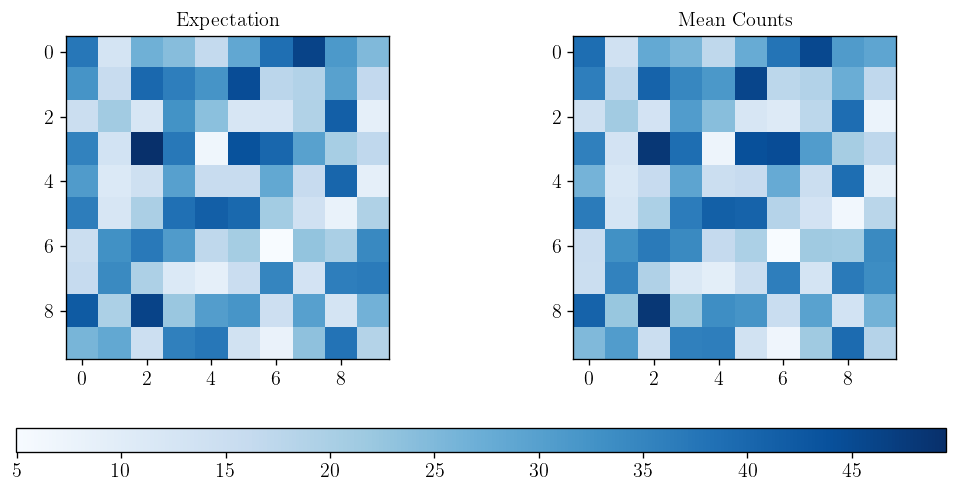

In [15]:
mean_counts = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(n_sim):
    mean_counts += data_s[i]
mean_counts /= float(n_sim)

expectation = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(5):
    if f'Sps_t{i}' in vd and vd[f'Sps_t{i}'] is not None:
        expectation += temps[i] * vd[f'Sps_t{i}']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.min(expectation), np.max(expectation)
axs[0].imshow(expectation.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
im = axs[1].imshow(mean_counts.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
axs[0].set_title('Expectation')
axs[1].set_title('Mean Counts');

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(temps[0].reshape(10, 10), cmap='Blues')
axs[1].imshow(temps[1].reshape(10, 10), cmap='Blues')
axs[0].set_title('Template 0')
axs[1].set_title('Template 1');

mean =  25.006


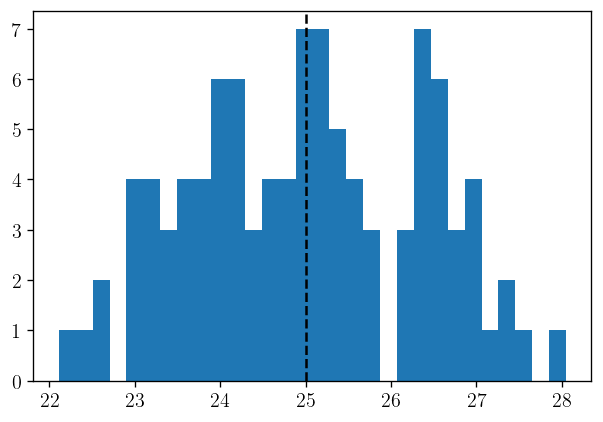

In [16]:
plt.hist(np.mean(data_s, axis=1), bins=30)
plt.axvline(np.mean(expectation), color='k', ls='--')
print('mean = ', np.mean(data_s))

## psf

In [7]:
sys.path.append("../nptfit")
from nptfit_func import *

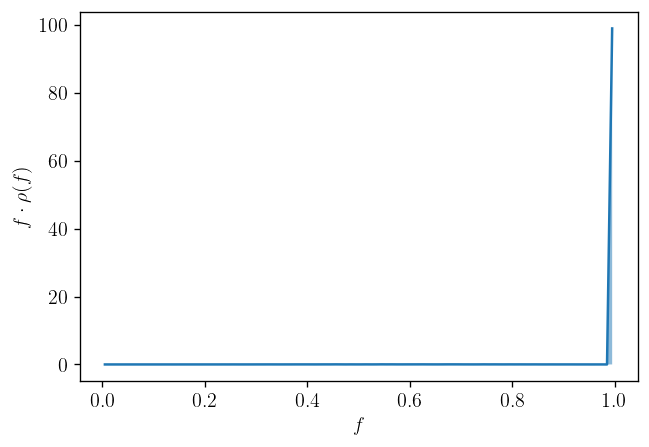

In [8]:
#psf_name = 'king'
psf_name = 'delta'
if psf_name == 'king':
    kp = KingPSF()
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)
elif psf_name == 'delta':
    sigma = np.deg2rad(0.001) / 3
    psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=100)

df = f_ary[1] - f_ary[0]
plot = True
if plot:
    plt.plot(f_ary, df_rho_div_f_ary/df*f_ary**2)
    plt.fill_between(f_ary, df_rho_div_f_ary/df*f_ary**2, 0., alpha=0.5)
    plt.ylabel(r'$f\cdot\rho(f)$')
    plt.xlabel(r'$f$');

In [9]:
np.sum(df_rho_div_f_ary*f_ary**2)

1.0000000000000002

In [10]:
df_rho_div_f_ary *= 0.
df_rho_div_f_ary[-1] = 1./(f_ary[-1]**2)

In [11]:
np.sum(df_rho_div_f_ary*f_ary**2)

1.0

## scan

In [12]:
pt_sum_compressed = np.full_like(temps[0], 1e-10)
npt_compressed = [temps[i] for i in range(5) if i in include_temps]

Sps_key = 't0'

Sps_arr = np.linspace(0.5*vd['Sps_'+Sps_key], 1.5*vd['Sps_'+Sps_key], 50)
#Sps_arr = np.linspace(0.1, 1, 50)

ll_ss = []
counts_arr = []
for data in tqdm(data_s[:50]):
    data = np.array(data, dtype=np.int32)
    ll_s = []
    counts_arr.append(np.sum(data))
    for Sps_target in Sps_arr:
        theta = []
        for i in include_temps:
            key = f't{i}'
            Sps = vd['Sps_'+key]
            if key == Sps_key:
                Sps = Sps_target
            
            s_intg = temp_s_intg_s[i] # expected counts for dndS with (1, n1, n2, n3, sb1, sb2)
            A = Sps / s_intg

            _, n1, n2, n3, sb1, sb2 = theta_unnorm_i(i, vd)
            theta.append([A, n1, n2, n3, sb1, sb2])

        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:10<00:00,  4.77it/s]


## plot

In [ ]:
vd

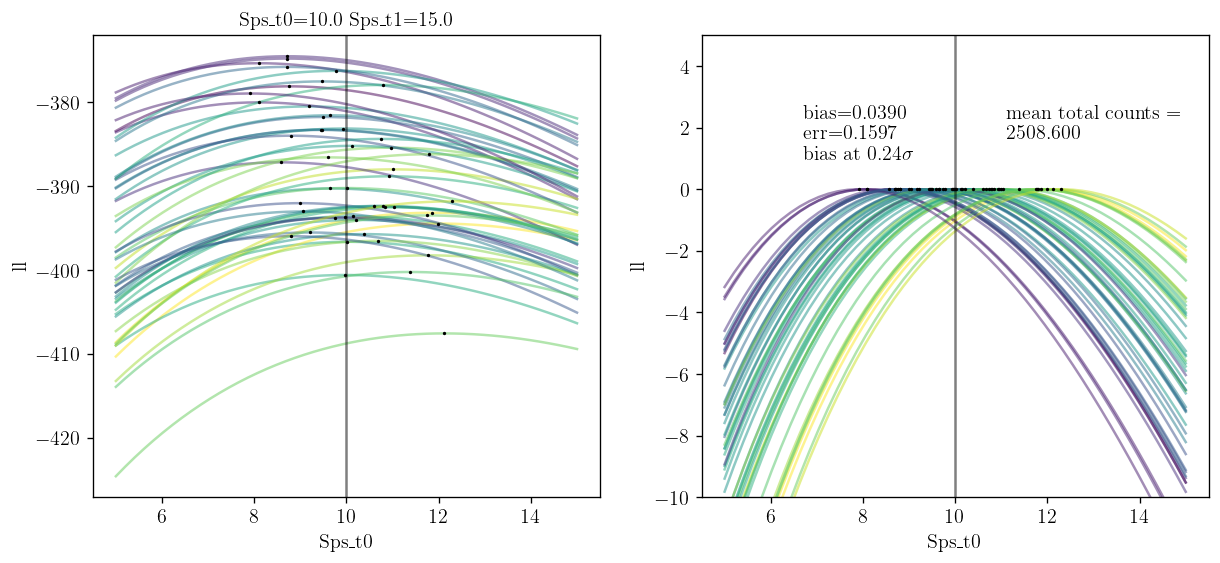

In [13]:
ll_ss = np.array(ll_ss).astype(np.float64)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []
Sps_s = Sps_arr

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in ['t0', 't1']])

ax = axs[0]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.2, 0.85, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$", transform=ax.transAxes, va='top')
ax.text(0.6, 0.85, f"mean total counts = \n{np.mean(counts_arr):.3f}", transform=ax.transAxes, va='top')
fig.savefig('ll.png', dpi=150)